In [53]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [69]:
df = pd.read_csv(r'D:ML\Project\netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [10]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [20]:
df.shape

(350, 11)

In [18]:
df.isna().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

Assigning Different Categories into Integers for Multiclass Classification

In [284]:
label_encoder = LabelEncoder()
df['Rating Encoded'] = label_encoder.fit_transform(df['rating'])
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,Rating Encoded,Listed_In_encoded,type Encoded,Director Encoded,Country Encoded
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",7,274,0,2295,603
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",11,414,1,4528,426
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,11,242,1,2105,736
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",11,297,1,4528,736
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,11,393,1,4528,251


In [77]:
df['country'].fillna('Unknown', inplace=True)
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,Rating Encoded
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",7
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",11
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,11
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",11
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,11


In [79]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df.drop_duplicates(inplace=True)
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,Rating Encoded
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",7
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",11
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,11
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",11
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,11


In [81]:
label_encoder = LabelEncoder()
df['Listed_In_encoded'] = label_encoder.fit_transform(df['listed_in'])
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,Rating Encoded,Listed_In_encoded
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",7,274
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",11,414
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,11,242
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",11,297
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,11,393
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,2019-11-20,2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a...",8,269
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,Unknown,2019-07-01,2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g...",14,424
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,2019-11-01,2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...,8,207
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2020-01-11,2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero...",6,125


In [83]:
label_encoder = LabelEncoder()
df['type Encoded'] = label_encoder.fit_transform(df['type'])
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,Rating Encoded,Listed_In_encoded,type Encoded
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",7,274,0
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",11,414,1
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,11,242,1
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",11,297,1
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,11,393,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,2019-11-20,2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a...",8,269,0
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,Unknown,2019-07-01,2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g...",14,424,1
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,2019-11-01,2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...,8,207,0
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2020-01-11,2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero...",6,125,0


In [93]:
label_encoder = LabelEncoder()
df['Director Encoded'] = label_encoder.fit_transform(df['director'])
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,Rating Encoded,Listed_In_encoded,type Encoded,Director Encoded,Country Encoded
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",7,274,0,2295,603
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",11,414,1,4528,426
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,11,242,1,2105,736
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",11,297,1,4528,736
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,11,393,1,4528,251


In [89]:
label_encoder = LabelEncoder()
df['Country Encoded'] = label_encoder.fit_transform(df['country'])
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,Rating Encoded,Listed_In_encoded,type Encoded,Director Encoded,Country Encoded
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",7,274,0,2295,603
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",11,414,1,4528,426
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,11,242,1,2105,736
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",11,297,1,4528,736
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,11,393,1,4528,251


In [95]:
df_movies = df[df['type'] == 'Movie'].copy()
df_movies['duration_minutes'] = df_movies['duration'].str.replace(' min', '').astype(float)
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,Rating Encoded,Listed_In_encoded,type Encoded,Director Encoded,Country Encoded
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",7,274,0,2295,603
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",11,414,1,4528,426
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,11,242,1,2105,736
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",11,297,1,4528,736
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,11,393,1,4528,251


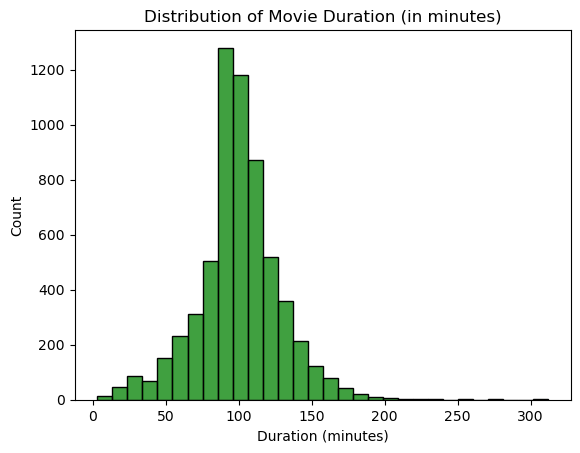

In [97]:
sns.histplot(df_movies['duration_minutes'], bins=30, color='green')
plt.title("Distribution of Movie Duration (in minutes)")
plt.xlabel("Duration (minutes)")
plt.ylabel("Count")
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_16748\246873374.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='type', palette='coolwarm')


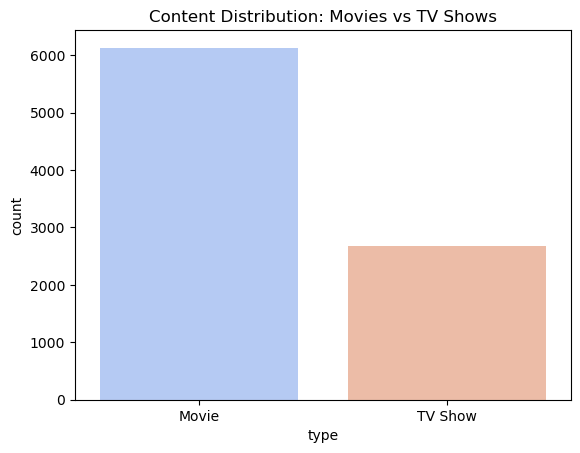

In [109]:
sns.countplot(data=df, x='type', palette='coolwarm')
plt.title("Content Distribution: Movies vs TV Shows")
plt.show()

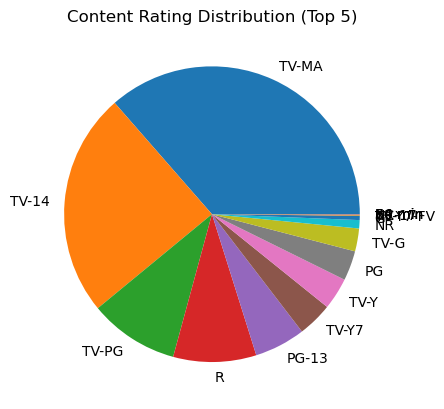

In [135]:
rating_counts = df['rating'].value_counts()
plt.pie(rating_counts, labels = rating_counts.index)
plt.title("Content Rating Distribution (Top 5)")
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_16748\957805937.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_directors.values, y=top_directors.index, palette='Set1')


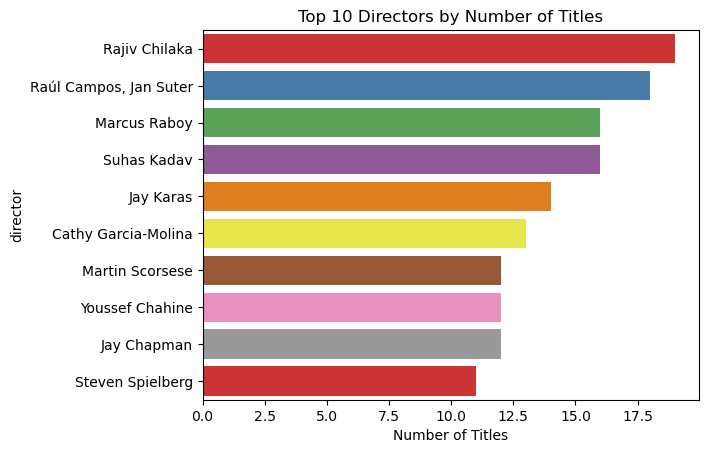

In [143]:
top_directors = df['director'].value_counts().head(10)
sns.barplot(x=top_directors.values, y=top_directors.index, palette='Set1')
plt.title("Top 10 Directors by Number of Titles")
plt.xlabel("Number of Titles")
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_16748\2688510969.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_movies, x='Rating Encoded', y='duration_minutes', palette='Set2')


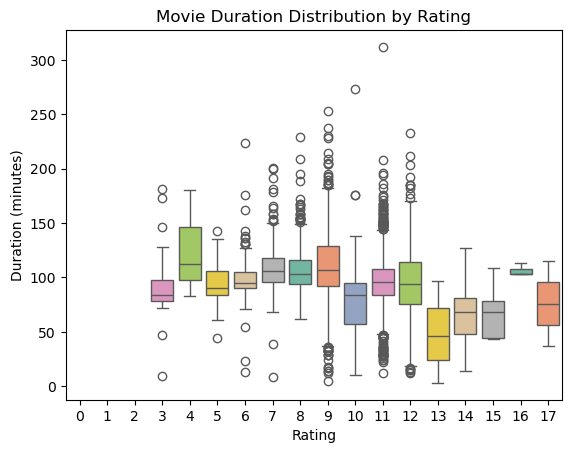

In [161]:
sns.boxplot(data=df_movies, x='Rating Encoded', y='duration_minutes', palette='Set2')
plt.title("Movie Duration Distribution by Rating")
plt.ylabel("Duration (minutes)")
plt.xlabel("Rating")
plt.show()

In [414]:
df_tv = df[df['type'] == 'TV Show'].copy()
df_tv['seasons'] = df_tv['duration'].str.replace(' Season', '').str.replace('s', '').astype(int)
df_tv.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,Rating Encoded,Listed_In_encoded,type Encoded,Director Encoded,Country Encoded,popular,seasons
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",11,414,1,4528,426,1,2
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,11,242,1,2105,736,1,1
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",11,297,1,4528,736,1,1
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,11,393,1,4528,251,1,2
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",Unknown,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...,11,499,1,2866,736,1,1


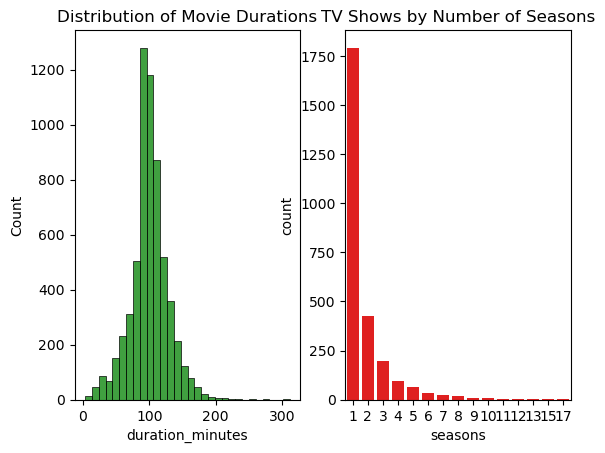

In [416]:
plt.subplot(1, 2, 1)
sns.histplot(df_movies['duration_minutes'], bins=30, color='green')
plt.title("Distribution of Movie Durations")
plt.subplot(1,2,2)
sns.countplot(data= df_tv, x='seasons', color='red')
plt.title("TV Shows by Number of Seasons")
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_16748\4082968282.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_top10,x='Listed_In_encoded', y=df['Listed_In_encoded'].sum(),palette='deep')


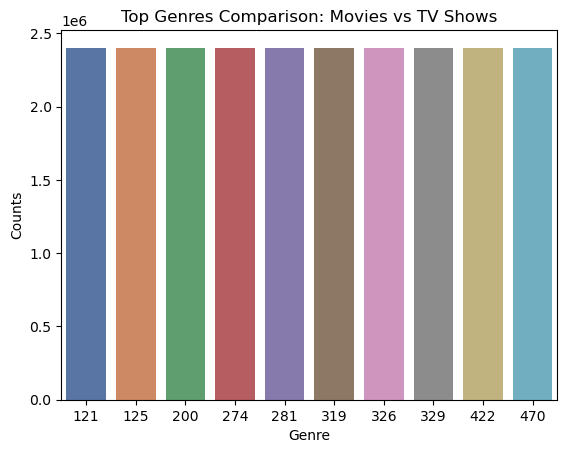

In [223]:
top_10_genre = df['Listed_In_encoded'].value_counts().head(10).index
df_top10 = df[df['Listed_In_encoded'].isin(top_10_genre)]
plt.title("Top Genres Comparison: Movies vs TV Shows")
sns.barplot(data=df_top10,x='Listed_In_encoded', y=df['Listed_In_encoded'].sum(),palette='deep')
plt.xlabel('Genre')
plt.ylabel('Counts')
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_16748\3280547972.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_top10,x='Director Encoded', y=df['Director Encoded'].sum(), palette='cool')


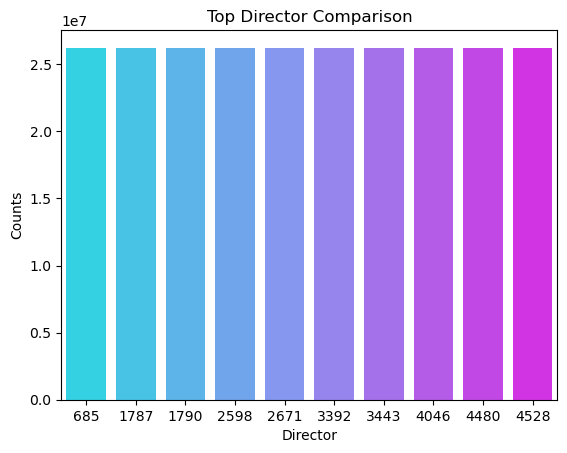

In [227]:
top_10_genre = df['Director Encoded'].value_counts().head(10).index
df_top10 = df[df['Director Encoded'].isin(top_10_genre)]
plt.title("Top Director Comparison")
sns.barplot(data=df_top10,x='Director Encoded', y=df['Director Encoded'].sum(), palette='cool')
plt.xlabel('Director')
plt.ylabel('Counts')
plt.show()

TASK 4 AI Powered Insights

In [252]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [244]:
#KMeans Clustering
#First I've to prepare the data
#Already Preprocessed
df[['type', 'type Encoded']].drop_duplicates()
tv_shows_df = df[df['type Encoded'] == 1].copy()
movies_df = df[df['type Encoded'] == 0].copy()

In [248]:
tv_shows_df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,Rating Encoded,Listed_In_encoded,type Encoded,Director Encoded,Country Encoded
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",11,414,1,4528,426
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,11,242,1,2105,736
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",11,297,1,4528,736
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,11,393,1,4528,251
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",Unknown,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...,11,499,1,2866,736


In [250]:
movies_df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,Rating Encoded,Listed_In_encoded,type Encoded,Director Encoded,Country Encoded
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",7,274,0,2295,603
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",Unknown,2021-09-24,2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,6,121,0,3542,736
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",11,319,0,1504,663
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021-09-24,2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...,7,197,0,4157,603
12,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic",2021-09-23,2021,TV-MA,127 min,"Dramas, International Movies",After most of her family is murdered in a terr...,11,326,0,792,218


C:\Users\user\AppData\Local\Temp\ipykernel_16748\1070500365.py:8: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=df_tv_cluster, x='duration_seasons', y='Rating Encoded', palette='coolwarm')


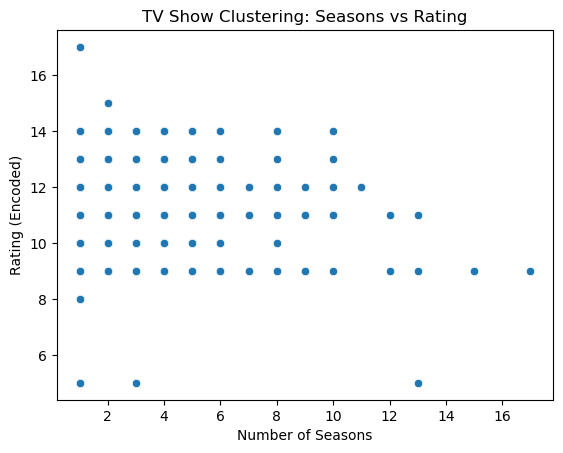

In [270]:
#Clustering for TV Shows
scaler = StandardScaler()
tv_shows_df['duration_seasons'] = tv_shows_df['duration'].str.replace(' Season', '').str.replace('s', '').astype(float)
df_tv_cluster = tv_shows_df[['Rating Encoded', 'Listed_In_encoded', 'duration_seasons']].dropna()
scaled_features = scaler.fit_transform(df_tv_cluster)
kmeans = KMeans(n_clusters=3, random_state=42)
df_tv_cluster['cluster'] = kmeans.fit_predict(scaled_features)
sns.scatterplot(data=df_tv_cluster, x='duration_seasons', y='Rating Encoded', palette='coolwarm')
plt.title("TV Show Clustering: Seasons vs Rating")
plt.xlabel("Number of Seasons")
plt.ylabel("Rating (Encoded)")
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_16748\2262160934.py:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=df_movie_cluster, x='duration_minutes', y='Rating Encoded', palette='deep')


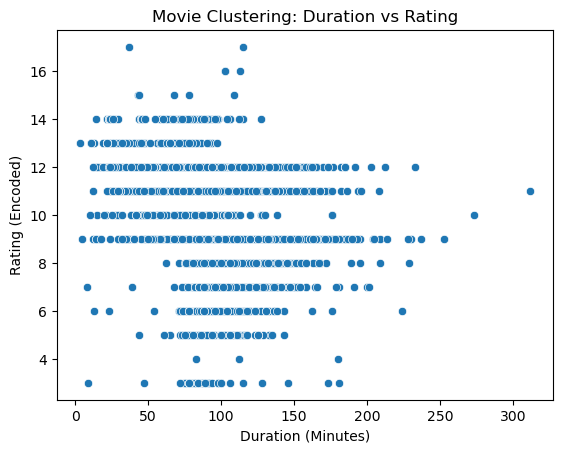

In [276]:
scaler = StandardScaler()
movies_df['duration_minutes'] = movies_df['duration'].str.replace(' min', '').astype(float)
df_movie_cluster = movies_df[['Rating Encoded', 'Listed_In_encoded', 'duration_minutes']].dropna()
scaled_features = scaler.fit_transform(df_movie_cluster)
kmeans = KMeans(n_clusters=3, random_state=42)
df_movie_cluster['cluster'] = kmeans.fit_predict(scaled_features)
sns.scatterplot(data=df_movie_cluster, x='duration_minutes', y='Rating Encoded', palette='deep')
plt.title("Movie Clustering: Duration vs Rating")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Rating (Encoded)")
plt.show()

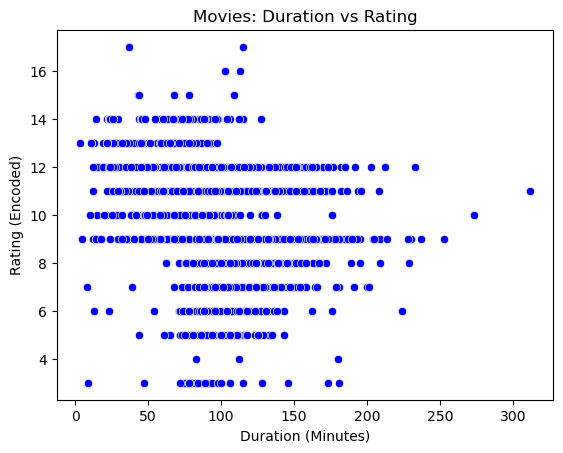

In [280]:
#USing AI (ChatGPT) for the suggestion
sns.scatterplot(data=movies_df, x='duration_minutes', y='Rating Encoded', color='blue')
plt.title("Movies: Duration vs Rating")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Rating (Encoded)")
plt.show()

In [390]:
#regression for Movies
#Prediction and 
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
movies_df = df[df['type Encoded'] == 0].copy()
movies_df['duration_minutes'] = movies_df['duration'].str.replace(' min', '').astype(float)
X_movies = movies_df[['Listed_In_encoded', 'duration_minutes']].fillna(0)
y_movies = movies_df['Rating Encoded']
X_train, X_test, y_train, y_test = train_test_split(X_movies, y_movies, test_size=0.25, random_state=42)
reg = LinearRegression()
reg.fit(X_train, y_train)
y_pred = reg.predict(X_test)
print(f"Movies Regression - MSE: {mean_squared_error(y_test, y_pred):.2f}")
print(f"Movies Regression - R² Score: {r2_score(y_test, y_pred):.2f}")

Movies Regression - MSE: 3.73
Movies Regression - R² Score: 0.07


In [386]:
reg.score(X_movies,y_movies)

0.06848192981973455

In [388]:
reg.predict([[5,75]])

C:\Users\user\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([9.61442714])

In [372]:
#Regression model for TV Shows
#Predicting the Rating for a random TV Shows
tv_shows_df = df[df['type Encoded'] == 1].copy()
tv_shows_df['duration_seasons'] = tv_shows_df['duration'].str.replace(' Season', '').str.replace('s', '').astype(float)
X_tv = tv_shows_df[['Listed_In_encoded', 'duration_seasons']].fillna(0)
y_tv = tv_shows_df['Rating Encoded']
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_tv, y_tv, test_size=0.30, random_state=42)
reg_tv = LinearRegression()
reg_tv.fit(X_train, y_train)
# Predictions
y_pred_tv = reg_tv.predict(X_test)
# Evaluation
print(f"TV Shows Regression - MSE: {mean_squared_error(y_test, y_pred_tv):.2f}")
print(f"TV Shows Regression - R² Score: {r2_score(y_test, y_pred_tv):.2f}")

TV Shows Regression - MSE: 2.14
TV Shows Regression - R² Score: 0.00


In [310]:
reg_tv.score(X_tv,y_tv)

0.003108019901199799

In [312]:
reg_tv.predict([[11,2]])

C:\Users\user\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([10.6657232])

In [392]:
#Using other Models for Movies
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score

movies_df = df[df['type Encoded'] == 0].copy()
movies_df['duration_minutes'] = movies_df['duration'].str.replace(' min', '').astype(float)

# Define Popularity (example: median rating as threshold)
threshold = movies_df['Rating Encoded'].median()
movies_df['popular'] = movies_df['Rating Encoded'].apply(lambda x: 1 if x >= threshold else 0)
X = movies_df[['Listed_In_encoded', 'duration_minutes']].fillna(0)
y = movies_df['popular']
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
# SVM
svm = SVC()
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.7129810828440966
              precision    recall  f1-score   support

           0       0.64      0.12      0.21       465
           1       0.72      0.97      0.82      1068

    accuracy                           0.71      1533
   macro avg       0.68      0.55      0.52      1533
weighted avg       0.69      0.71      0.64      1533



In [394]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.7860404435746902
              precision    recall  f1-score   support

           0       0.65      0.62      0.64       465
           1       0.84      0.86      0.85      1068

    accuracy                           0.79      1533
   macro avg       0.75      0.74      0.74      1533
weighted avg       0.78      0.79      0.78      1533



In [396]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

KNN Accuracy: 0.7873450750163079
              precision    recall  f1-score   support

           0       0.69      0.55      0.61       465
           1       0.82      0.89      0.85      1068

    accuracy                           0.79      1533
   macro avg       0.75      0.72      0.73      1533
weighted avg       0.78      0.79      0.78      1533



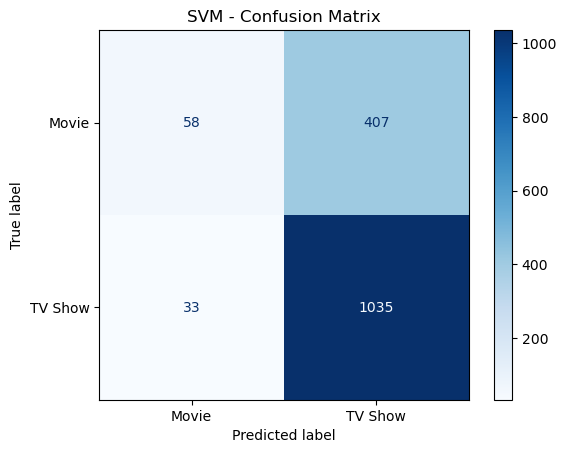

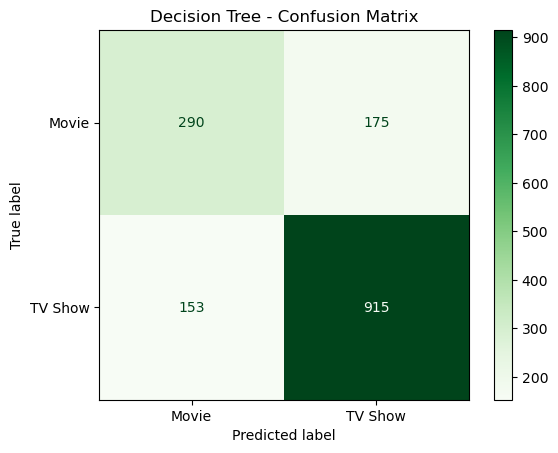

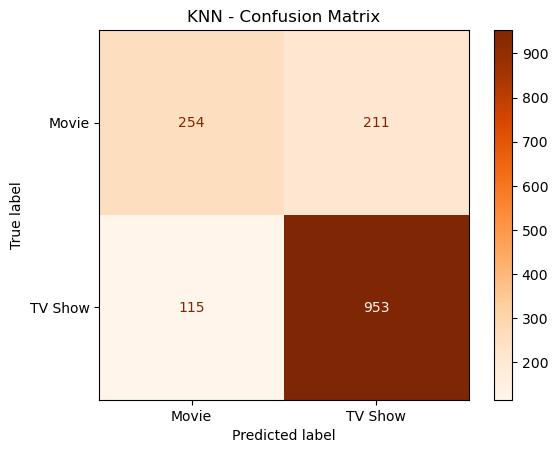

In [398]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Example for SVM
cm_svm = confusion_matrix(y_test, y_pred_svm)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=["Movie", "TV Show"])
disp_svm.plot(cmap='Blues')
plt.title("SVM - Confusion Matrix")
plt.show()

# Decision Tree
cm_dt = confusion_matrix(y_test, y_pred_dt)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=["Movie", "TV Show"])
disp_dt.plot(cmap='Greens')
plt.title("Decision Tree - Confusion Matrix")
plt.show()

# KNN
cm_knn = confusion_matrix(y_test, y_pred_knn)
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=["Movie", "TV Show"])
disp_knn.plot(cmap='Oranges')
plt.title("KNN - Confusion Matrix")
plt.show()

In [356]:
threshold = df['Rating Encoded'].median()
df['popular'] = df['Rating Encoded'].apply(lambda x: 1 if x >= threshold else 0)
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,Rating Encoded,Listed_In_encoded,type Encoded,Director Encoded,Country Encoded,popular
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",7,274,0,2295,603,0
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",11,414,1,4528,426,1
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,11,242,1,2105,736,1
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",11,297,1,4528,736,1
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,11,393,1,4528,251,1


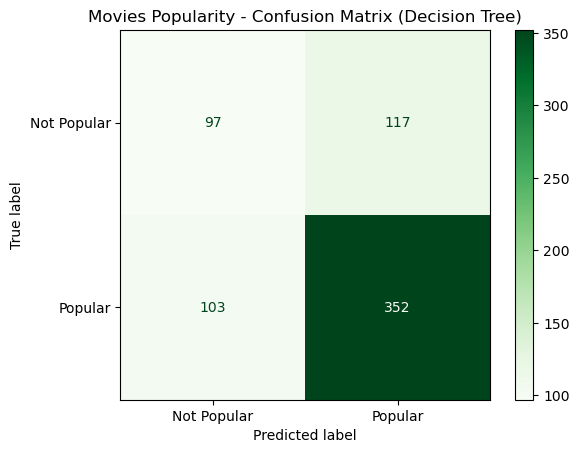

ValueError: Could not interpret value `duration_minutes` for `y`. An entry with this name does not appear in `data`.

In [412]:
cm = confusion_matrix(y_test, y_pred_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Popular", "Popular"])
disp.plot(cmap='Greens')
plt.title("Movies Popularity - Confusion Matrix (Decision Tree)")
plt.show()

# Scatter Plot
test_results = X_test.copy()
test_results['Predicted Popular'] = y_pred_dt

sns.scatterplot(data=test_results, x='Listed_In_encoded', y='duration_minutes', hue='Predicted Popular', palette='coolwarm')
plt.title("Movies Popularity Prediction (Decision Tree)")
plt.xlabel("Genre (Encoded)")
plt.ylabel("Duration (minutes)")
plt.show()

In [400]:
#Using other models for TV Shows
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score

tv_shows_df = df[df['type Encoded'] == 1].copy()
tv_shows_df['duration_seasons'] = tv_shows_df['duration'].str.replace(' Season', '').str.replace('s', '').astype(float)

# Define Popularity (example: median rating as threshold)
threshold = tv_shows_df['Rating Encoded'].median()
tv_shows_df['popular'] = tv_shows_df['Rating Encoded'].apply(lambda x: 1 if x >= threshold else 0)
X1 = tv_shows_df[['Listed_In_encoded', 'duration_seasons']].fillna(0)
y1 = tv_shows_df['popular']
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X1, y1, test_size=0.25, random_state=42)
# SVM
svm = SVC()
svm.fit(X_train, y_train)
y_pred_svm1 = svm.predict(X_test)
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm1))
print(classification_report(y_test, y_pred_svm1))

SVM Accuracy: 0.680119581464873
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       214
           1       0.68      1.00      0.81       455

    accuracy                           0.68       669
   macro avg       0.34      0.50      0.40       669
weighted avg       0.46      0.68      0.55       669



C:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [402]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.6711509715994021
              precision    recall  f1-score   support

           0       0.48      0.45      0.47       214
           1       0.75      0.77      0.76       455

    accuracy                           0.67       669
   macro avg       0.62      0.61      0.62       669
weighted avg       0.67      0.67      0.67       669



In [404]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

KNN Accuracy: 0.6547085201793722
              precision    recall  f1-score   support

           0       0.45      0.37      0.41       214
           1       0.73      0.79      0.76       455

    accuracy                           0.65       669
   macro avg       0.59      0.58      0.58       669
weighted avg       0.64      0.65      0.65       669



In [406]:
threshold = df['Rating Encoded'].median()
df['popular'] = df['Rating Encoded'].apply(lambda x: 1 if x >= threshold else 0)
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,Rating Encoded,Listed_In_encoded,type Encoded,Director Encoded,Country Encoded,popular
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",7,274,0,2295,603,0
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",11,414,1,4528,426,1
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,11,242,1,2105,736,1
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",11,297,1,4528,736,1
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,11,393,1,4528,251,1


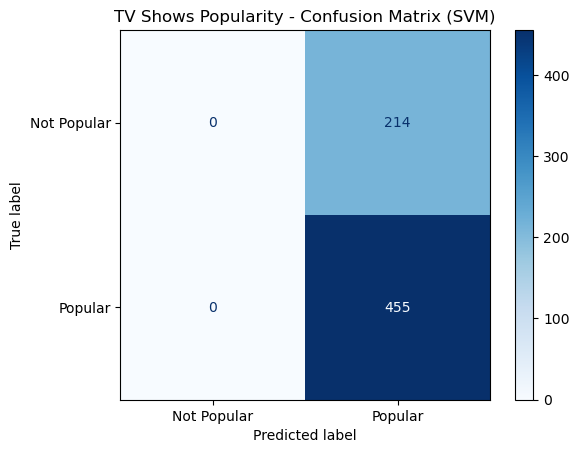

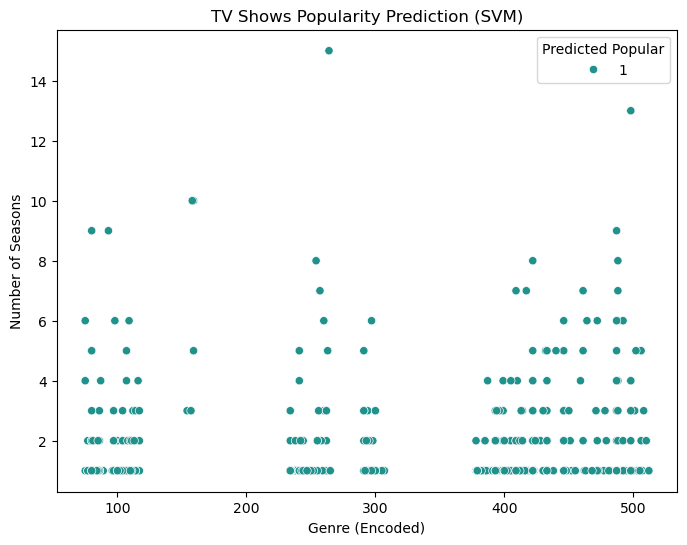

In [410]:
tv_df = df[df['type Encoded'] == 1].copy()
tv_df['duration_seasons'] = tv_df['duration'].str.replace(' Season', '').str.replace('s', '').astype(float)

# Binary Popularity Target
threshold = tv_df['Rating Encoded'].median()
tv_df['popular'] = tv_df['Rating Encoded'].apply(lambda x: 1 if x >= threshold else 0)

# Features & Target
X_tv = tv_df[['Listed_In_encoded', 'duration_seasons']].fillna(0)
y_tv = tv_df['popular']

# Train-Test Split
X_train_tv, X_test_tv, y_train_tv, y_test_tv = train_test_split(X_tv, y_tv, test_size=0.25, random_state=42)

# Train SVM Example
from sklearn.svm import SVC
svm_tv = SVC()
svm_tv.fit(X_train_tv, y_train_tv)
y_pred_tv = svm_tv.predict(X_test_tv)

# Confusion Matrix
cm_tv = confusion_matrix(y_test_tv, y_pred_tv)
disp_tv = ConfusionMatrixDisplay(confusion_matrix=cm_tv, display_labels=["Not Popular", "Popular"])
disp_tv.plot(cmap='Blues')
plt.title("TV Shows Popularity - Confusion Matrix (SVM)")
plt.show()

# Scatter Plot
test_results_tv = X_test_tv.copy()
test_results_tv['Predicted Popular'] = y_pred_tv

sns.scatterplot(data=test_results_tv, x='Listed_In_encoded', y='duration_seasons', hue='Predicted Popular', palette='viridis')
plt.title("TV Shows Popularity Prediction (SVM)")
plt.xlabel("Genre (Encoded)")
plt.ylabel("Number of Seasons")
plt.show()